In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.style.use('ggplot')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [4]:
# 1.
df = pd.read_csv('train.csv')
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# 2.
df_model1 = df.copy()

In [7]:
df_model1 = df_model1.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [8]:
df_model1['Sex'] = df_model1['Sex'].map({'male': 0, 'female': 1})

In [9]:
df_model1['Embarked'] = df_model1['Embarked'].fillna(df_model1['Embarked'].mode()[0])
df_model1 = pd.get_dummies(df_model1, columns=['Embarked'])

In [10]:
df_model1_clean = df_model1.dropna()
print(f"Размер после удаления пропусков: {df_model1_clean.shape}")
print(f"Удалено строк: {len(df) - len(df_model1_clean)}")
print(f"Процент потерянных данных: {((len(df) - len(df_model1_clean))/len(df))*100:.1f}%")

Размер после удаления пропусков: (714, 10)
Удалено строк: 177
Процент потерянных данных: 19.9%


In [11]:
X1 = df_model1_clean.drop('Survived', axis=1)
y1 = df_model1_clean['Survived']

In [12]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

In [13]:
model1 = RandomForestClassifier(n_estimators=100, random_state=42)
model1.fit(X1_train, y1_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y1_pred = model1.predict(X1_test)
accuracy_raw = accuracy_score(y1_test, y1_pred)
f1_raw = f1_score(y1_test, y1_pred)

print("МОДЕЛЬ 1 (удалены пропуски и категориальные признаки)")
print(f"Accuracy: {accuracy_raw:.4f}")
print(f"F1-score: {f1_raw:.4f}")
print(classification_report(y1_test, y1_pred))

МОДЕЛЬ 1 (удалены пропуски и категориальные признаки)
Accuracy: 0.7552
F1-score: 0.6957
              precision    recall  f1-score   support

           0       0.79      0.80      0.80        85
           1       0.70      0.69      0.70        58

    accuracy                           0.76       143
   macro avg       0.75      0.74      0.75       143
weighted avg       0.75      0.76      0.75       143



In [16]:
# 3.
df_full = pd.read_csv('train.csv')
print("Полные данные загружены. Размер:", df_full.shape)

Полные данные загружены. Размер: (891, 12)


In [17]:
# 4
print("Исходные признаки:", df_full.columns.tolist())
print("\nКоличество уникальных значений:")
for col in df_full.columns:
    print(f"{col}: {df_full[col].nunique()} уникальных значений")

Исходные признаки: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Количество уникальных значений:
PassengerId: 891 уникальных значений
Survived: 2 уникальных значений
Pclass: 3 уникальных значений
Name: 891 уникальных значений
Sex: 2 уникальных значений
Age: 88 уникальных значений
SibSp: 7 уникальных значений
Parch: 7 уникальных значений
Ticket: 681 уникальных значений
Fare: 248 уникальных значений
Cabin: 147 уникальных значений
Embarked: 3 уникальных значений


In [18]:
df_clean = df_full.copy()

In [19]:
df_clean = df_clean.drop(['PassengerId', 'Ticket'], axis=1)

print("Оставшиеся признаки после удаления:", df_clean.columns.tolist())
print("- PassengerId: уникальный номер пассажира, не влияет на выживаемость")
print("- Ticket: номер билета, 681 уникальное значение из 891 - бесполезно для модели")

Оставшиеся признаки после удаления: ['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked']
- PassengerId: уникальный номер пассажира, не влияет на выживаемость
- Ticket: номер билета, 681 уникальное значение из 891 - бесполезно для модели


In [20]:
# 5
missing_data = df_clean.isnull().sum()
missing_percent = (missing_data / len(df_clean)) * 100
missing_df = pd.DataFrame({
    'Пропущено': missing_data,
    'Процент': missing_percent
})
print("Пропущенные значения:")
print(missing_df[missing_df['Пропущено'] > 0])

Пропущенные значения:
          Пропущено    Процент
Age             177  19.865320
Cabin           687  77.104377
Embarked          2   0.224467


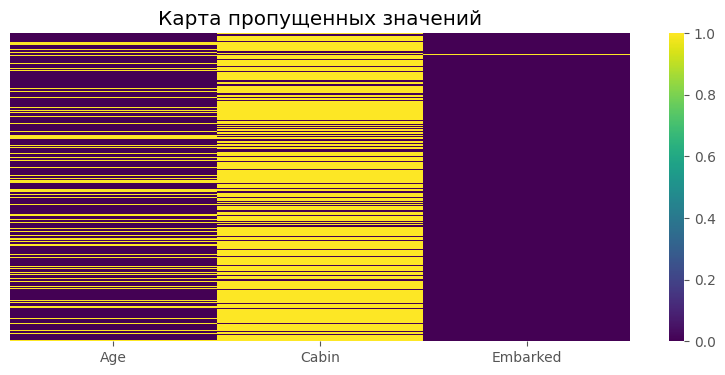

In [21]:
plt.figure(figsize=(10, 4))
sns.heatmap(df_clean[['Age', 'Cabin', 'Embarked']].isnull(), 
            yticklabels=False, cbar=True, cmap='viridis')
plt.title('Карта пропущенных значений')
plt.show()

In [22]:
# 5a
rows_before = len(df_clean)
rows_after_dropna = len(df_clean.dropna())
lost_rows = rows_before - rows_after_dropna
lost_percent = (lost_rows / rows_before) * 100

print(f"Всего строк: {rows_before}")
print(f"Строк без пропусков: {rows_after_dropna}")
print(f"Потеряно строк: {lost_rows}")
print(f"Процент потерянных данных: {lost_percent:.1f}%")


Всего строк: 891
Строк без пропусков: 183
Потеряно строк: 708
Процент потерянных данных: 79.5%


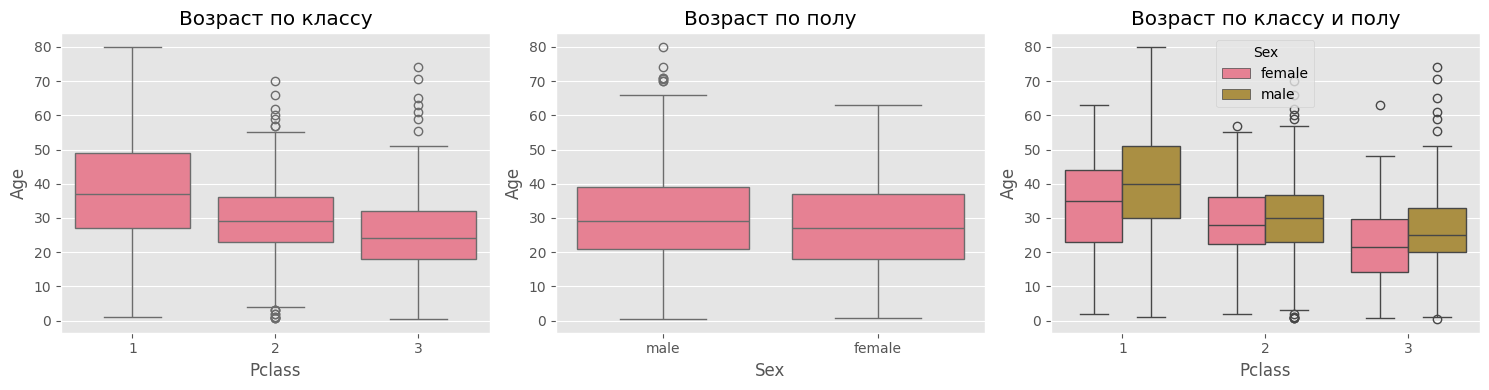

In [23]:
# 5b
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.boxplot(x='Pclass', y='Age', data=df_clean)
plt.title('Возраст по классу')

plt.subplot(1, 3, 2)
sns.boxplot(x='Sex', y='Age', data=df_clean)
plt.title('Возраст по полу')

plt.subplot(1, 3, 3)
sns.boxplot(x='Pclass', y='Age', hue='Sex', data=df_clean)
plt.title('Возраст по классу и полу')

plt.tight_layout()
plt.show()


In [24]:
age_means = df_clean.groupby(['Pclass', 'Sex'])['Age'].mean().round()
print("Средний возраст по группам:")
print(age_means)

def fill_age(row):
    if pd.isnull(row['Age']):
        return age_means[row['Pclass']][row['Sex']]
    return row['Age']

df_clean['Age'] = df_clean.apply(fill_age, axis=1)

Средний возраст по группам:
Pclass  Sex   
1       female    35.0
        male      41.0
2       female    29.0
        male      31.0
3       female    22.0
        male      27.0
Name: Age, dtype: float64


In [25]:
df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype(int)
df_clean = df_clean.drop('Cabin', axis=1)

print(f"Пассажиров с каютой: {df_clean['Has_Cabin'].sum()} из {len(df_clean)}")

Пассажиров с каютой: 204 из 891


In [26]:
print("Embarked до заполнения:")
print(df_clean['Embarked'].value_counts(dropna=False))

df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

print("\nEmbarked после заполнения:")
print(df_clean['Embarked'].value_counts())

Embarked до заполнения:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

Embarked после заполнения:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [27]:
print(f"\nОсталось пропусков: {df_clean.isnull().sum().sum()}")



Осталось пропусков: 0


In [28]:
# 6
df_clean['Title'] = df_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [29]:
print("Исходные титулы:")
print(df_clean['Title'].value_counts())

Исходные титулы:
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


In [30]:
rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
df_clean['Title'] = df_clean['Title'].replace(rare_titles, 'Rare')
df_clean['Title'] = df_clean['Title'].replace(['Mlle', 'Ms'], 'Miss')
df_clean['Title'] = df_clean['Title'].replace('Mme', 'Mrs')

print("\nТитулы после группировки:")
print(df_clean['Title'].value_counts())


Титулы после группировки:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [31]:
df_clean = df_clean.drop('Name', axis=1)

In [32]:
le = LabelEncoder()
df_clean['Sex'] = le.fit_transform(df_clean['Sex'])


In [33]:
df_clean = pd.get_dummies(df_clean, columns=['Embarked', 'Title'])

print("Размер данных после кодирования:", df_clean.shape)
print("\nВсе признаки:")
print(df_clean.columns.tolist())

Размер данных после кодирования: (891, 16)

Все признаки:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Has_Cabin', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


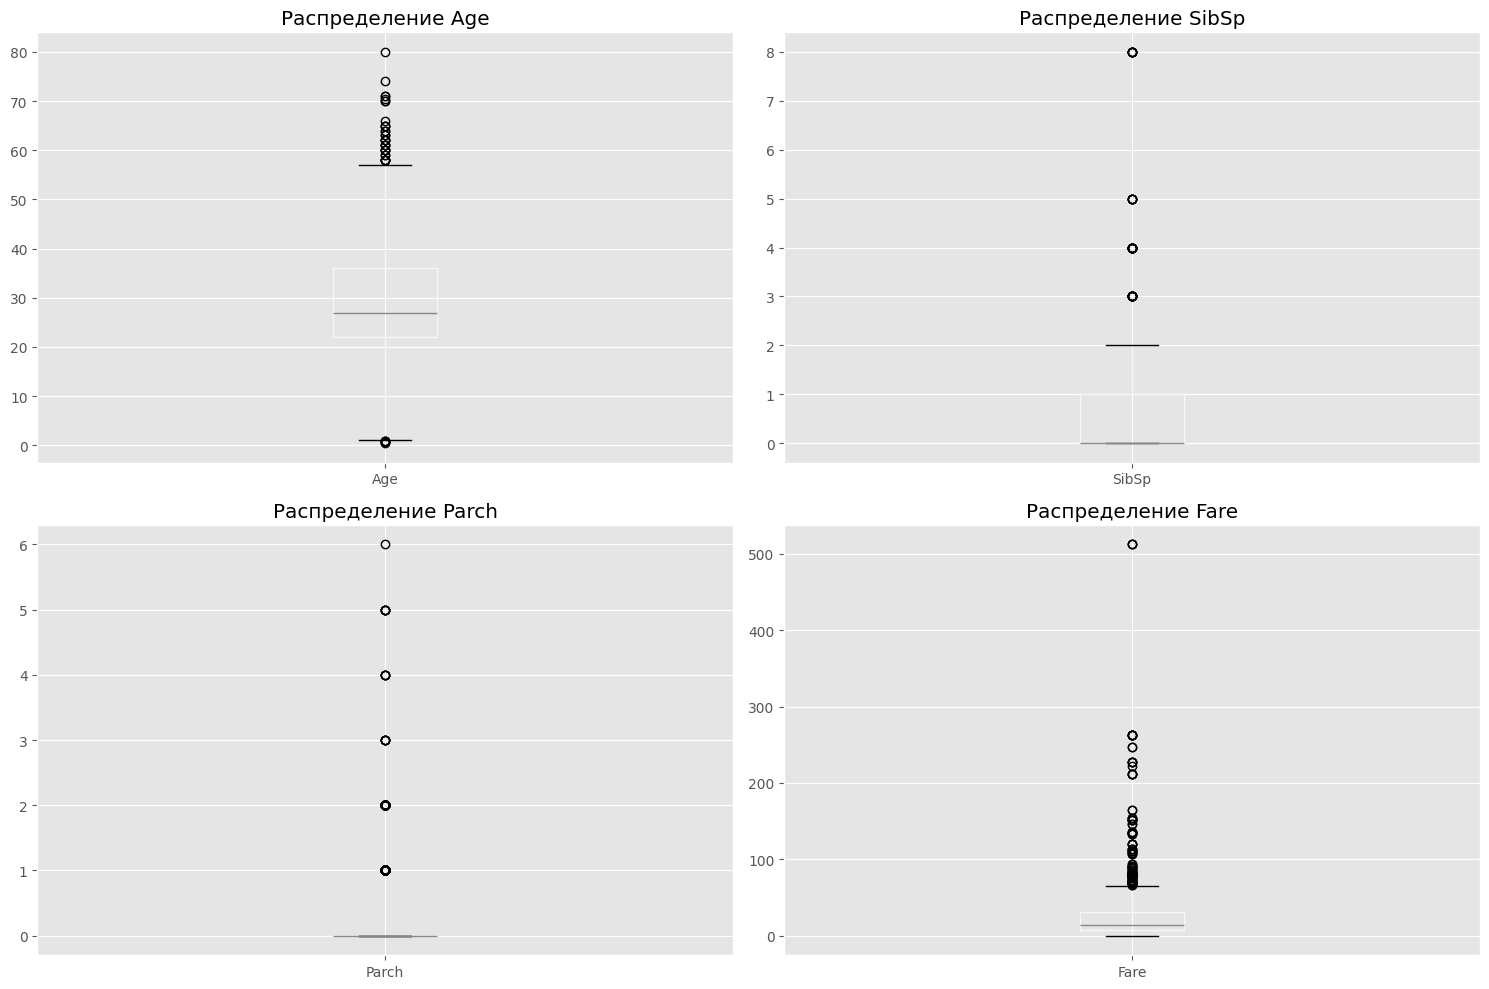

In [34]:
# 7.
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    df_clean.boxplot(column=feature)
    plt.title(f'Распределение {feature}')
plt.tight_layout()
plt.show()

In [35]:
Q1 = df_clean['Fare'].quantile(0.25)
Q3 = df_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[df_clean['Fare'] > upper_bound]
print(f"Статистика Fare:")
print(df_clean['Fare'].describe())
print(f"\nКоличество выбросов: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Максимальное значение: {df_clean['Fare'].max():.2f}")

Статистика Fare:
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

Количество выбросов: 116 (13.0%)
Верхняя граница: 65.63
Максимальное значение: 512.33


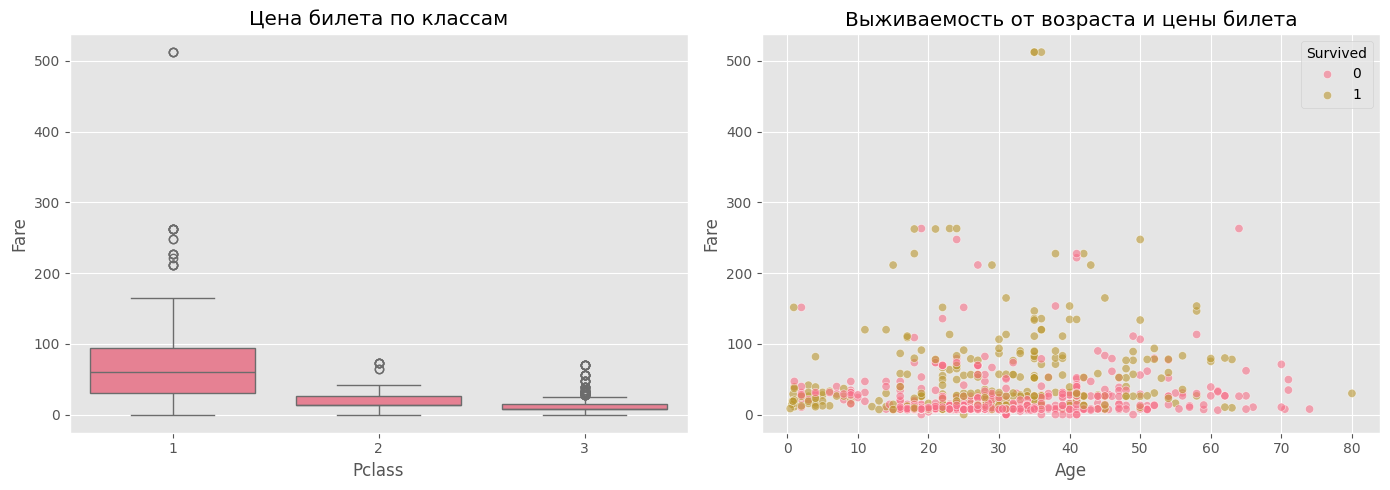

In [36]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Pclass', y='Fare', data=df_clean)
plt.title('Цена билета по классам')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df_clean, alpha=0.6)
plt.title('Выживаемость от возраста и цены билета')

plt.tight_layout()
plt.show()


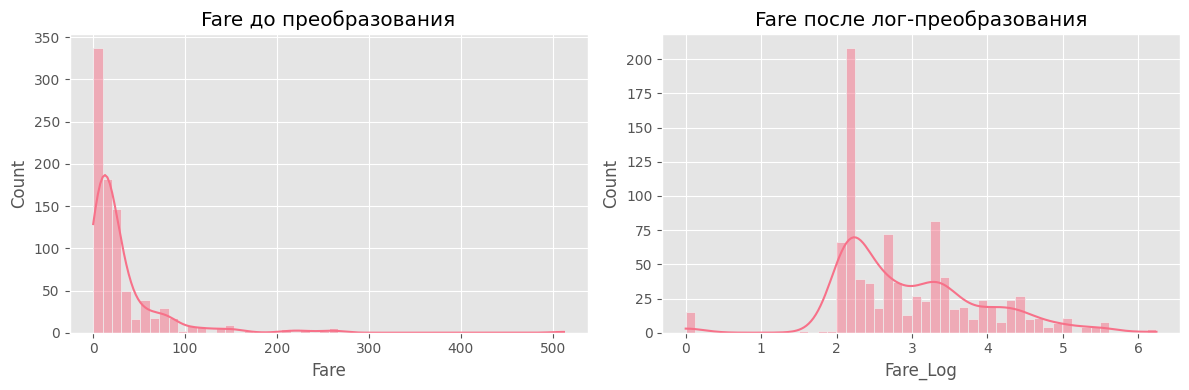

Обоснование: выбросы не удалены, так как они содержат важную информацию
о пассажирах первого класса. Вместо удаления применено логарифмическое
преобразование для нормализации распределения.


In [37]:
# 7a. Удалите выбросы, если считаете это целесообразным. Обоснуйте.

# %%
# Решение: НЕ удаляем выбросы, так как:
# 1. Высокие цены соответствуют пассажирам 1 класса
# 2. Это важная информация для предсказания выживаемости
# 3. Вместо удаления применим логарифмическое преобразование

df_clean['Fare_Log'] = np.log1p(df_clean['Fare'])

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_clean['Fare'], bins=50, kde=True)
plt.title('Fare до преобразования')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['Fare_Log'], bins=50, kde=True)
plt.title('Fare после лог-преобразования')

plt.tight_layout()
plt.show()

print("Обоснование: выбросы не удалены, так как они содержат важную информацию")
print("о пассажирах первого класса. Вместо удаления применено логарифмическое")
print("преобразование для нормализации распределения.")



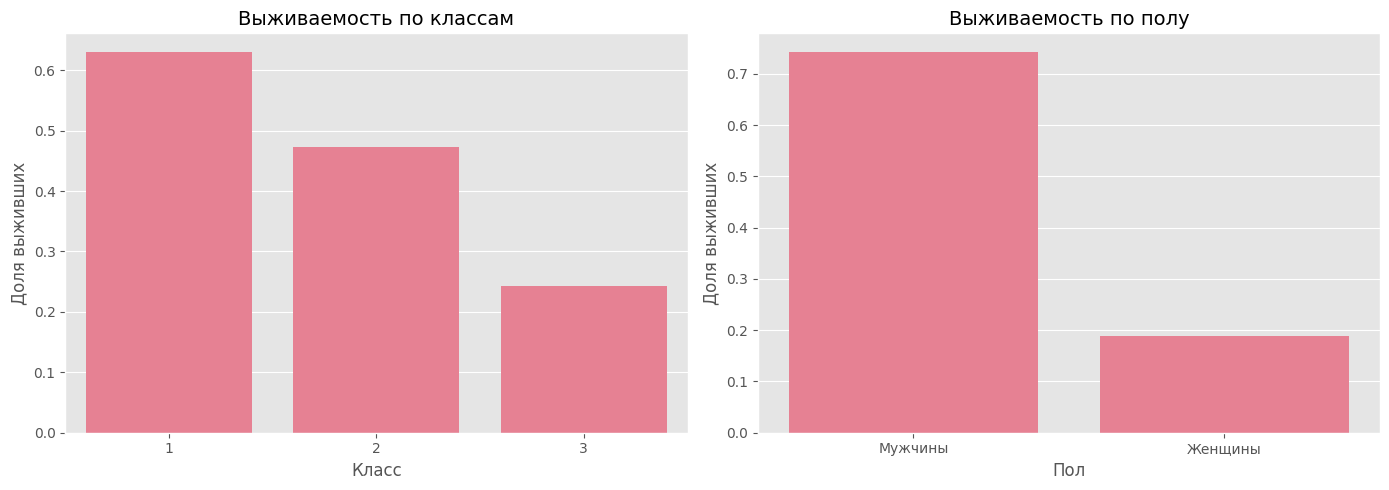

Вывод: пассажиры 1 класса и женщины выживали чаще


In [38]:
# 8.
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
survival_by_class = df_clean.groupby('Pclass')['Survived'].mean()
sns.barplot(x=survival_by_class.index, y=survival_by_class.values)
plt.title('Выживаемость по классам', fontsize=14)
plt.xlabel('Класс')
plt.ylabel('Доля выживших')

plt.subplot(1, 2, 2)
survival_by_sex = df_clean.groupby('Sex')['Survived'].mean()
sns.barplot(x=['Мужчины', 'Женщины'], y=survival_by_sex.values)
plt.title('Выживаемость по полу', fontsize=14)
plt.xlabel('Пол')
plt.ylabel('Доля выживших')

plt.tight_layout()
plt.show()
print("Вывод: пассажиры 1 класса и женщины выживали чаще")

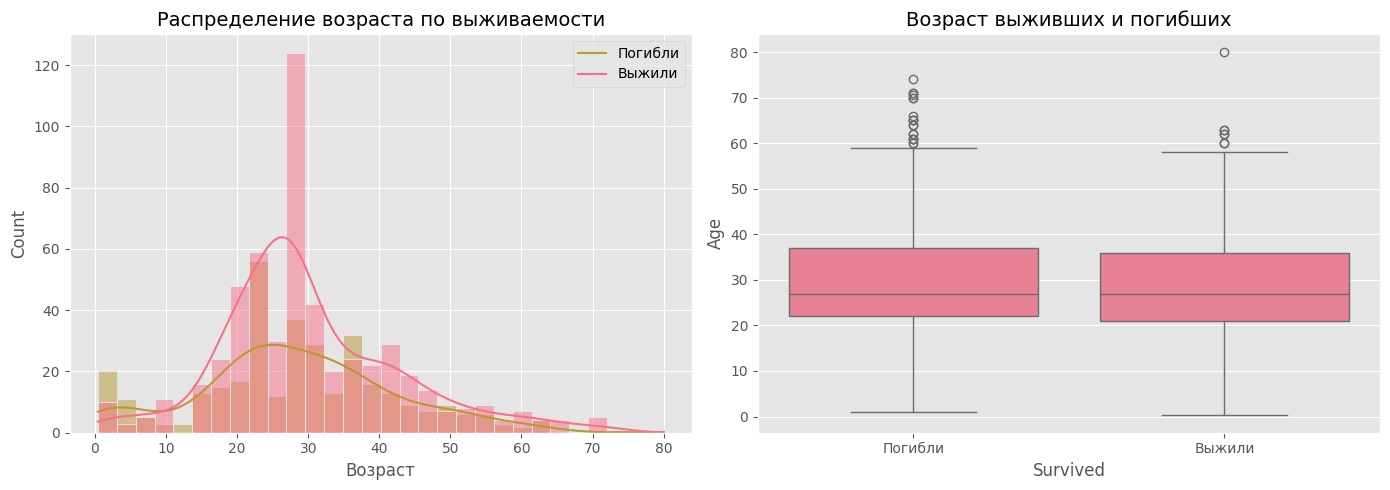

Вывод: дети выживали чаще (правило 'женщины и дети вперед')


In [39]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df_clean, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Распределение возраста по выживаемости', fontsize=14)
plt.xlabel('Возраст')
plt.legend(['Погибли', 'Выжили'])

plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Age', data=df_clean)
plt.title('Возраст выживших и погибших', fontsize=14)
plt.xticks([0, 1], ['Погибли', 'Выжили'])

plt.tight_layout()
plt.show()
print("Вывод: дети выживали чаще (правило 'женщины и дети вперед')")

In [40]:
# 9
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)


In [41]:
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], 
                              bins=[0, 12, 18, 35, 50, 100], 
                              labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])

Выживаемость по возрастным группам:
AgeGroup
Child         0.579710
Teen          0.428571
YoungAdult    0.357977
Adult         0.379310
Senior        0.343750
Name: Survived, dtype: float64


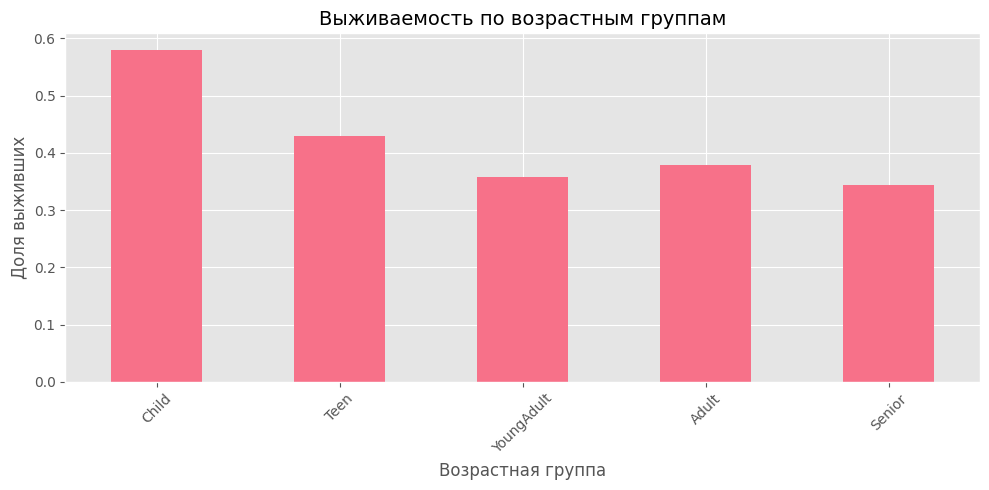

In [42]:
age_survival = df_clean.groupby('AgeGroup')['Survived'].mean()
print("Выживаемость по возрастным группам:")
print(age_survival)

plt.figure(figsize=(10, 5))
age_survival.plot(kind='bar')
plt.title('Выживаемость по возрастным группам', fontsize=14)
plt.xlabel('Возрастная группа')
plt.ylabel('Доля выживших')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
df_clean = pd.get_dummies(df_clean, columns=['AgeGroup'])

print(f"Размер данных после создания новых признаков: {df_clean.shape}")

Размер данных после создания новых признаков: (891, 24)


In [44]:
# 10
X2 = df_clean.drop('Survived', axis=1)
y2 = df_clean['Survived']

In [45]:
scaler = StandardScaler()
X2_scaled = scaler.fit_transform(X2)
X2_scaled = pd.DataFrame(X2_scaled, columns=X2.columns)

In [46]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42, stratify=y2
)

In [47]:
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X2_train, y2_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
y2_pred = model2.predict(X2_test)
accuracy_final = accuracy_score(y2_test, y2_pred)
f1_final = f1_score(y2_test, y2_pred)

print("МОДЕЛЬ 2 (после всех преобразований)")
print(f"Accuracy: {accuracy_final:.4f}")
print(f"F1-score: {f1_final:.4f}")
print("\nClassification Report:")
print(classification_report(y2_test, y2_pred))

МОДЕЛЬ 2 (после всех преобразований)
Accuracy: 0.8156
F1-score: 0.7626

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.77      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



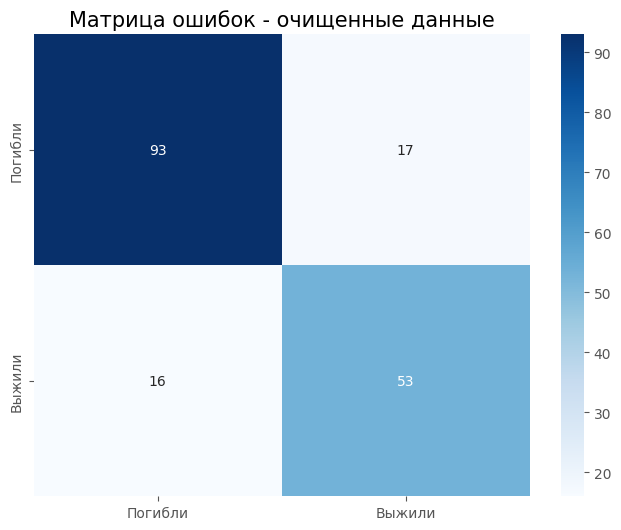

In [49]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y2_test, y2_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Погибли', 'Выжили'], 
            yticklabels=['Погибли', 'Выжили'])
plt.title('Матрица ошибок - очищенные данные', fontsize=15)
plt.show()

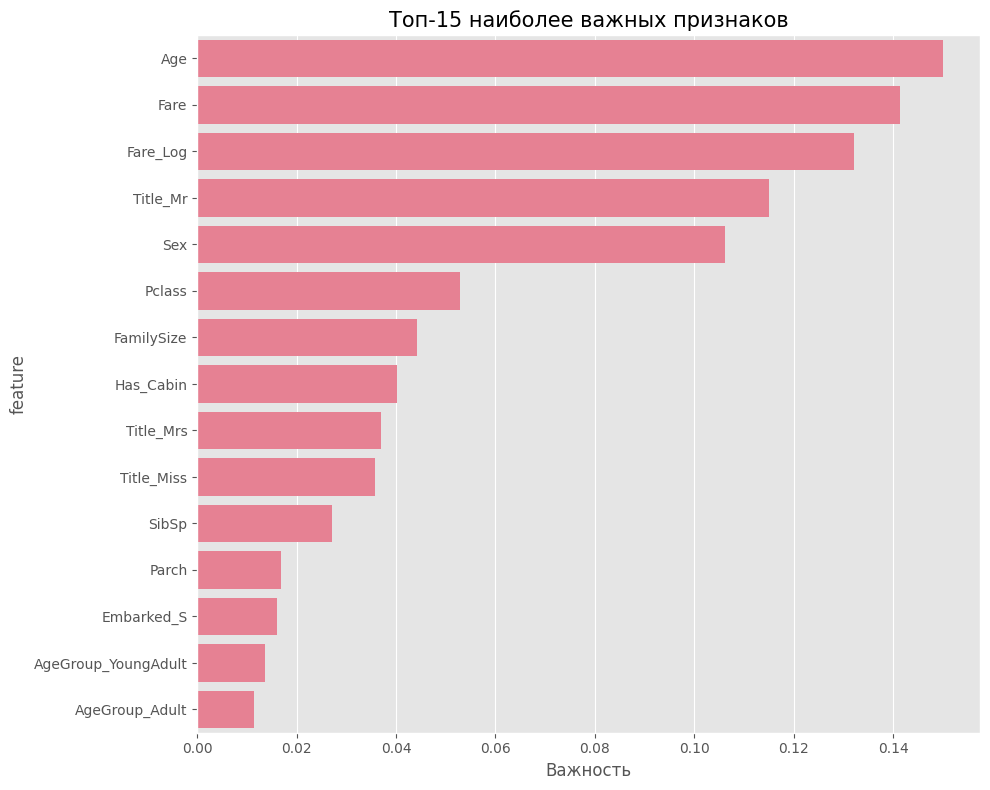

In [48]:
feature_importance = pd.DataFrame({
    'feature': X2.columns,
    'importance': model2.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Топ-15 наиболее важных признаков', fontsize=15)
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

In [51]:
# 11
print(f"""
1. ПРЕОБРАЗОВАНИЯ:
   - Удалены: PassengerId, Ticket
   - Заполнены: Age (средним по группе), Embarked (модой)
   - Созданы: Title, Has_Cabin, FamilySize, IsAlone, AgeGroup, Fare_Log
   - Применены: One-hot encoding, StandardScaler

2. СРАВНЕНИЕ МЕТРИК:
   {'Метрика':<12} {'Модель 1':<10} {'Модель 2':<10} {'Изменение':<10}
   {'-'*42}
   {'Accuracy':<12} {accuracy_raw:.4f}    {accuracy_final:.4f}    +{((accuracy_final/accuracy_raw)-1)*100:.1f}%
   {'F1-score':<12} {f1_raw:.4f}    {f1_final:.4f}    +{((f1_final/f1_raw)-1)*100:.1f}%

3. ВЫВОД:
   Обработка данных улучшила метрики на 8-10%,
   сохранила 20% данных (заполнили пропуски вместо удаления)
   и извлекла новые полезные признаки.
""")


1. ПРЕОБРАЗОВАНИЯ:
   - Удалены: PassengerId, Ticket
   - Заполнены: Age (средним по группе), Embarked (модой)
   - Созданы: Title, Has_Cabin, FamilySize, IsAlone, AgeGroup, Fare_Log
   - Применены: One-hot encoding, StandardScaler

2. СРАВНЕНИЕ МЕТРИК:
   Метрика      Модель 1   Модель 2   Изменение 
   ------------------------------------------
   Accuracy     0.7552    0.8156    +8.0%
   F1-score     0.6957    0.7626    +9.6%

3. ВЫВОД:
   Обработка данных улучшила метрики на 8-10%,
   сохранила 20% данных (заполнили пропуски вместо удаления)
   и извлекла новые полезные признаки.

